# Heart Disease Classification Project

## Predictiing Heart disease using machine learning

This notebook looks into using various Python-based machine learning and data science libraries in an attempt to build machine learning models capable of predicting whether or not someone has heart disease based on some medical attributes.

We're going to take the following approach
1. Problem Definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation

## 1. Problem Definition

> Given clinical parameters about a patient , can we predict whether or not they have heart disease?

## 2. Data

The original data came from the UCI Machine Learning Repository:https://archive.ics.uci.edu/dataset/45/heart+disease

## 3. Evaluation

> If we can reach 95% accuracy at predicting whether or not a patient has heart disease during the proof of concept , we'll pursue the project



## 4. Features
      1. (age)       
      2. (sex)       
      3. (cp)        
      4. (trestbps)  
      5. (chol)      
      6. (fbs)       
      7. (restecg)   
      8. (thalach)   
      9. (exang)     
      10. (oldpeak)   
      11. (slope)     
      12. (ca)        
      13. (thal)      
      14. (target) 


## Prepare the tools

We're going to use pandas, Matplotlib,Numpy for data analysis/manipulation.

In [1]:
#Import the tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

%matplotlib inline

## Load Data

In [2]:
data=pd.read_csv("heart-disease (2).csv")

## Data exploration(Exploratory data analysis or EDA)

The goal here is to find out more about the data and become a subject matter export on the dataset you are working with.

1. What question(s) are you trying to solve?
2. What kind of data do we have and how we treat different types?
3. What's missing from the data and how do you deal with it?
4. Where are the outliers and why should you care about them?'
5. How can you add , change or remove features to get out more of your data?

In [3]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
data["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

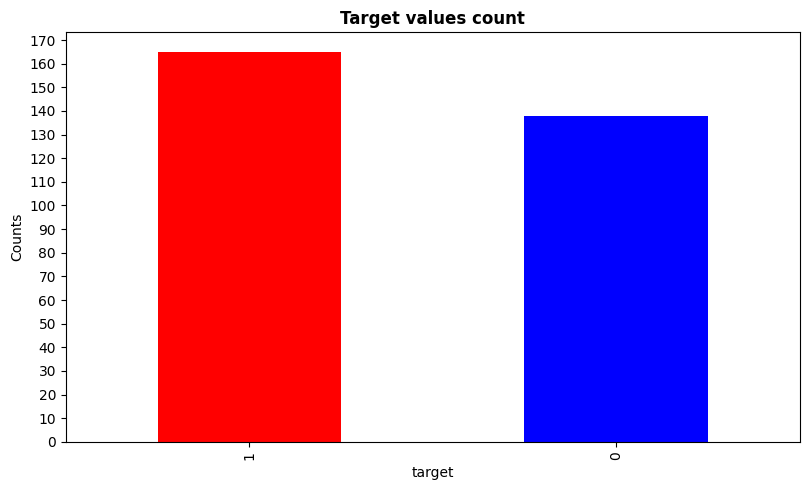

In [5]:
data["target"].value_counts().plot(kind="bar",
                                   color=["red","blue"],
                                   figsize=(8,5));
plt.title("Target values count",fontweight="bold")
plt.tight_layout()
plt.ylabel("Counts")
plt.yticks(np.arange(0,180,10));

In [6]:
#Are there any missing values?
data.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### Heart Disease Frequency according to Sex

In [7]:
data["sex"].value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [8]:
#Compare target column with sex column
pd.crosstab(data["target"],data["sex"])

sex,0,1
target,,
0,24,114
1,72,93


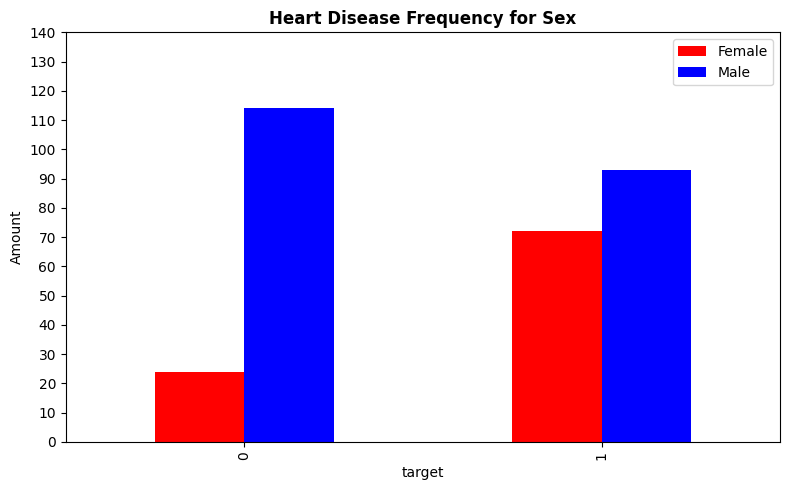

In [9]:
pd.crosstab(data["target"],data["sex"]).plot(kind="bar",
                                             color=["red","blue"],
                                             figsize=(8,5))

plt.title("Heart Disease Frequency for Sex",fontweight="bold")
plt.ylabel("Amount")
plt.tight_layout()
plt.yticks(np.arange(0,150,10))
plt.legend(["Female","Male"]);

### Age vs Max Heart Rate for Heart Disease`

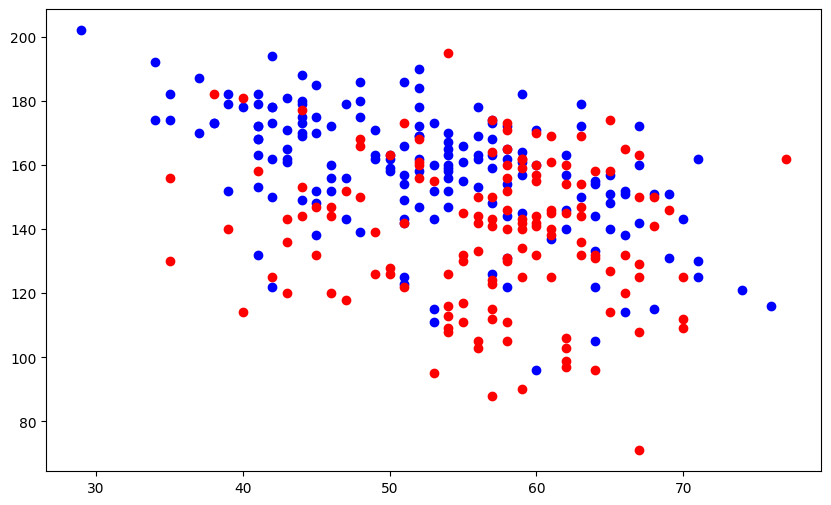

In [10]:
#Create another figure
plt.figure(figsize=(10,6))

#Scatter with positive examples
plt.scatter(data.age[data.target==1],
            data.thalach[data.target==1],
            c="blue");

plt.scatter(data.age[data.target==0],
            data.thalach[data.target==0],
            c="red");

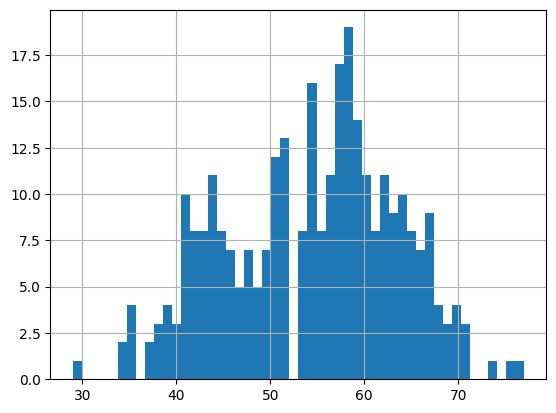

In [11]:
# Check the distribution of the age column with a histogram
data.age.hist(bins=50);

### Heart Disease Frequency per Cholesterol Levels

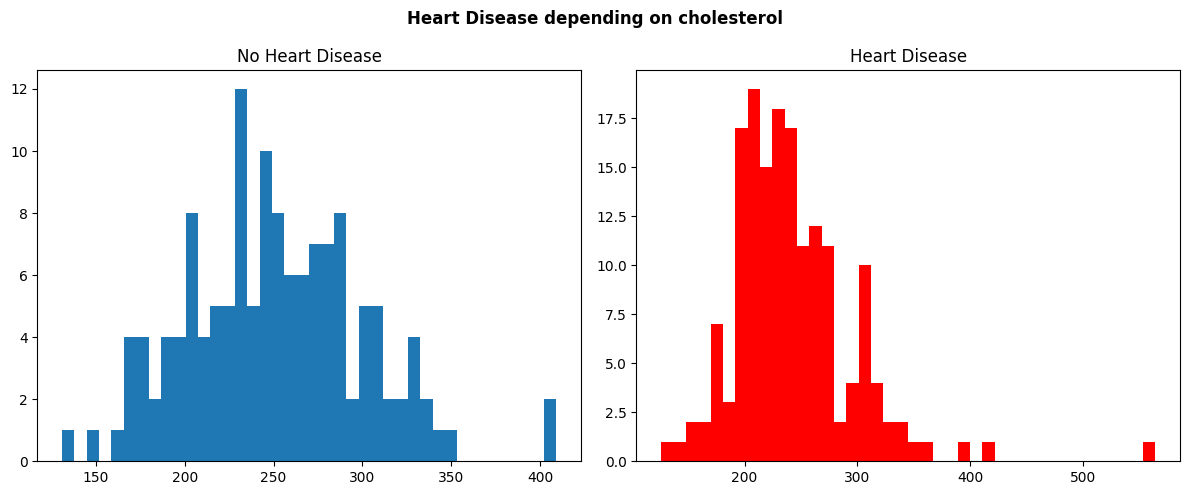

In [12]:
fig,(ax1,ax2)=plt.subplots(1,2)
fig.suptitle("Heart Disease depending on cholesterol",fontweight="bold");
fig.set_size_inches(12, 5)


ax1.hist(data[data["target"]==0]["chol"],bins=40);
ax1.set_title("No Heart Disease")

ax2.hist(data[data["target"]==1]["chol"],bins=40,color="red")
ax2.set_title("Heart Disease");
plt.tight_layout()

### Heart Disease Frequency per Chest Pain Type

In [13]:
pd.crosstab(data["cp"],data["target"])

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


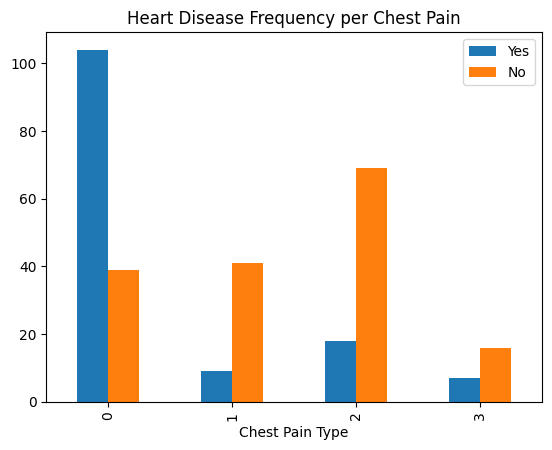

In [14]:
#Make the crosstab more visual
pd.crosstab(data["cp"],data["target"]).plot(kind="bar")
plt.legend(["Yes", "No"])
plt.title("Heart Disease Frequency per Chest Pain")
plt.xlabel("Chest Pain Type");

In [15]:
# Make a correlation matrix 
data.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


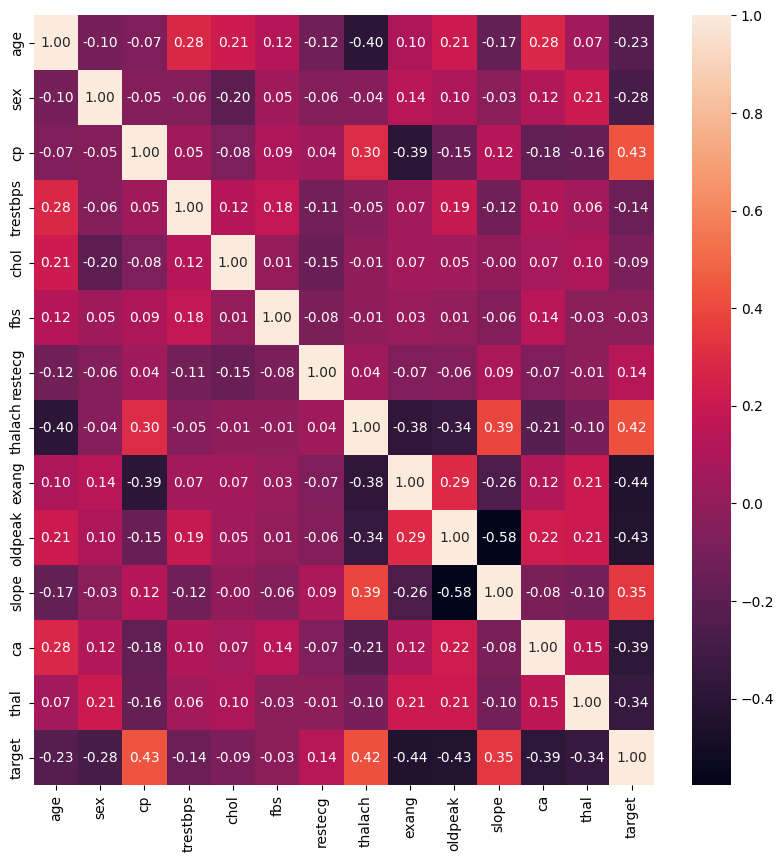

In [16]:
corr_matrix=data.corr()
fig, ax=plt.subplots(figsize=(10,10))

ax=sns.heatmap(corr_matrix,
               annot=True,
               fmt=".2f")

## 5. Modelling

In [17]:
# Split the data into X & y

X=data.drop("target", axis=1)
y=data["target"]

In [18]:
from sklearn.model_selection import train_test_split

np.random.seed(42)

#Split into train and test splits
X_train, X_test, y_train, y_test= train_test_split(X, y , test_size=0.2)

#Scaling
scaler= StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.fit_transform(X_test)

Now we've got our data split in train and test splits it's time to train 
a Machine learning model

Three different Machine Learning Models are used: 
1. Logistic Regression
2. K- Nearest Neighbors Classifier
3. Random Forest Classifier

In [90]:
# Put models in adictionary

models={"Logistic Regression": LogisticRegression(max_iter=100),
        "KNN":KNeighborsClassifier(),
        "Random Forest": RandomForestClassifier()}

#Create a function to fit and score models

def fit_and_score(models, X_train, X_test, y_train, y_test):
    #Set random seed
    np.random.seed(42)
    #Make a dictionary to keep model scores
    model_score={}
    for name,model in models.items():
        model.fit(X_train, y_train)
        model_score[name]=model.score(X_test, y_test)
    return model_score

results=fit_and_score(models, X_train, X_test, y_train, y_test)
results

{'Logistic Regression': 0.8852459016393442,
 'KNN': 0.9016393442622951,
 'Random Forest': 0.8524590163934426}

Let's look at the following:
* Hyperparameter tuning
* Feature importance
* Confusion matrix
* Cross-validation
* Precision
* Recall
* F1 score
* Classification report
* ROC curve
* Area under the curve

### Hyperparameter Tuning with RandomizedSearchCV

We're going to tune:
* LogisticRegression()
* RandomForestClassifier()
using RandomizedSearchCV

In [118]:
#Create a hyperparameter grid for Logistic Regression

log_reg_grid={"C": np.logspace(-4,4,20),
              "solver":["liblinear","newton-cg","lbfgs","sag"],
              "penalty":["l1","l2","elasticnet","none"]}

#Create a hyperparameter grid for RandomForestClassifier

rf_grid={"n_estimators": np.arange(10,1000,50),
         "max_depth": [None,10,20],
         "min_samples_split": [2,5],
         "min_samples_leaf": [1,2],
         "bootstrap":[True, False]}

In [119]:
#Tune Logistic Regression

np.random.seed(42)

#Setup random hyperparameter search for LogisticRegression
rs_log_reg=RandomizedSearchCV(LogisticRegression(),
                              param_distributions=log_reg_grid,
                              cv=5,
                              n_iter=20,
                              verbose=2)

In [120]:
#Fit random hyperparameter search for LogisticRegression
rs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END ........C=1.623776739188721, penalty=l2, solver=sag; total time=   0.0s
[CV] END ........C=1.623776739188721, penalty=l2, solver=sag; total time=   0.0s
[CV] END ........C=1.623776739188721, penalty=l2, solver=sag; total time=   0.0s
[CV] END ........C=1.623776739188721, penalty=l2, solver=sag; total time=   0.0s
[CV] END ........C=1.623776739188721, penalty=l2, solver=sag; total time=   0.0s
[CV] END ......C=78.47599703514607, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ......C=78.47599703514607, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ......C=78.47599703514607, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ......C=78.47599703514607, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ......C=78.47599703514607, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END C=0.00026366508987303583, penalty=elasticnet, solver=newton-cg; total time=   0.0s
[CV] END C=0.00026366508987303583, p

C:\Users\argyp\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\argyp\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\argyp\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalt

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.0000...00000000e+04]), 'penalty': ['l1', 'l2', ...], 'solver': ['liblinear', 'newton-cg', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` de

In [121]:
rs_log_reg.best_params_

{'solver': 'sag', 'penalty': 'l2', 'C': np.float64(1.623776739188721)}

In [131]:
rs_log_reg.score(X_test, y_test)

0.8852459016393442

In [132]:
#Tune RandomForestClassifier

np.random.seed(42)

#Setup random hyperparameter search for RandomForest
rs_rf=RandomizedSearchCV(RandomForestClassifier(),
                           param_distributions=rf_grid,
                           cv=5,
                           n_iter=20,
                           verbose=2)

In [133]:
#Fit RandomizedSearchCV for RandomForest

rs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=660; total time=   0.6s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=660; total time=   0.5s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=660; total time=   0.5s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=660; total time=   0.5s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=660; total time=   0.6s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=710; total time=   0.4s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=710; total time=   0.5s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=710; total ti

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 

In [134]:
#Find the best hyperparameters

rs_rf.best_params_

{'n_estimators': np.int64(660),
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_depth': None,
 'bootstrap': True}

In [135]:
# Evaluate the randomized search RandomForestClassifier model
rs_rf.score(X_test,y_test)

0.8688524590163934

## Hyperparameter Tuning with GridSearchCV

In [140]:
#Different hyperparameters for our LogisticRegression model
log_reg_grid={"C":np.logspace(-4,4,30),
              "solver":["liblinear"]}

#Setup grid hyperparameter search for LogisticRegression
gs_log_reg= GridSearchCV(LogisticRegression(),
                        param_grid=log_reg_grid,
                        cv=5,
                        verbose=2)

In [141]:
#Fit the model
gs_log_reg.fit(X_train, y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END .........................C=0.0001, solver=liblinear; total time=   0.0s
[CV] END .........................C=0.0001, solver=liblinear; total time=   0.0s
[CV] END .........................C=0.0001, solver=liblinear; total time=   0.0s
[CV] END .........................C=0.0001, solver=liblinear; total time=   0.0s
[CV] END .........................C=0.0001, solver=liblinear; total time=   0.0s
[CV] END .........C=0.00018873918221350977, solver=liblinear; total time=   0.0s
[CV] END .........C=0.00018873918221350977, solver=liblinear; total time=   0.0s
[CV] END .........C=0.00018873918221350977, solver=liblinear; total time=   0.0s
[CV] END .........C=0.00018873918221350977, solver=liblinear; total time=   0.0s
[CV] END .........C=0.00018873918221350977, solver=liblinear; total time=   0.0s
[CV] END ..........C=0.0003562247890262444, solver=liblinear; total time=   0.0s
[CV] END ..........C=0.0003562247890262444, sol

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the

In [142]:
#Check the best hyperparams
gs_log_reg.best_params_

{'C': np.float64(0.01610262027560939), 'solver': 'liblinear'}

In [144]:
#Evaluate the model
gs_log_reg.score(X_test, y_test)

0.8852459016393442

In [149]:
# Different hyperparameters for our RandomForest Classifier
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

gs_random_forest= GridSearchCV(RandomForestClassifier(),
                               param_grid=random_forest_grid,
                               cv=5,
                               verbose=2)

In [150]:
# Fit the model
gs_random_forest.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.5s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.5s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True, False], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

In [151]:
gs_random_forest.best_params_

{'bootstrap': True,
 'max_depth': 20,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}

In [152]:
gs_random_forest.score(X_test, y_test)

0.8688524590163934

## Evaluating our tuned machine learning classifier, beyond accuracy

* ROC curve and AUC score
* Confusion matrix
* Classification report
* Precision
* Recall
* F1-score

... and it would be great if cross-validation was used where possible

In [154]:
 #Make predictions with tuned model
y_preds=gs_log_reg.predict(X_test)
print("Grid Search CV Logistic Regression results:",y_preds)

y_preds2=gs_random_forest.predict(X_test)
print("Grid Search CV Random Forest results:",y_preds)


Grid Search CV Logistic Regression results: [0 1 1 0 1 1 1 0 0 1 1 0 1 0 1 1 1 0 0 0 1 0 0 1 1 1 1 1 0 1 0 0 0 0 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0]
Grid Search CV Random Forest results: [0 1 1 0 1 1 1 0 0 1 1 0 1 0 1 1 1 0 0 0 1 0 0 1 1 1 1 1 0 1 0 0 0 0 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0]


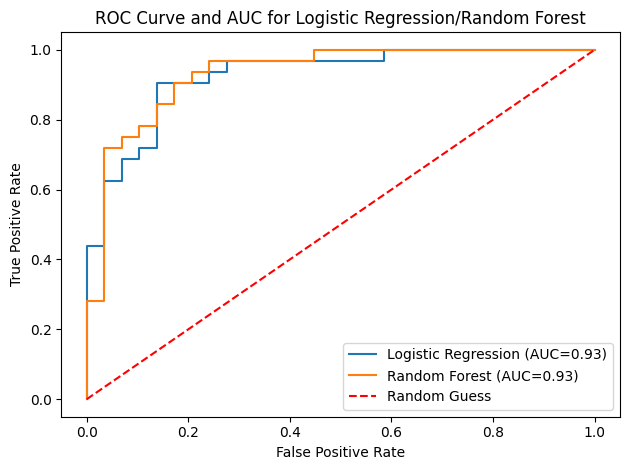

In [214]:
#Import ROC curve from sklearn.metrics
from sklearn.metrics import RocCurveDisplay,roc_curve,auc

#Plot ROC curve and calculate AUC
y_scores=gs_log_reg.predict_proba(X_test)[:,1]
fpr, tpr,_=roc_curve(y_test,y_scores)
roc_auc=auc(fpr,tpr)

y2_scores=gs_random_forest.predict_proba(X_test)[:,1]
fpr2,tpr2,_=roc_curve(y_test, y2_scores)
roc_auc2=auc(fpr2,tpr2)

plt.figure()
plt.plot(fpr,tpr,label=f'Logistic Regression (AUC={roc_auc:.2f})')
plt.plot(fpr2,tpr2,label=f'Random Forest (AUC={roc_auc2:.2f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve and AUC for Logistic Regression/Random Forest")
plt.tight_layout()
plt.legend()
plt.show()

In [36]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test,y_preds))

[[25  4]
 [ 3 29]]


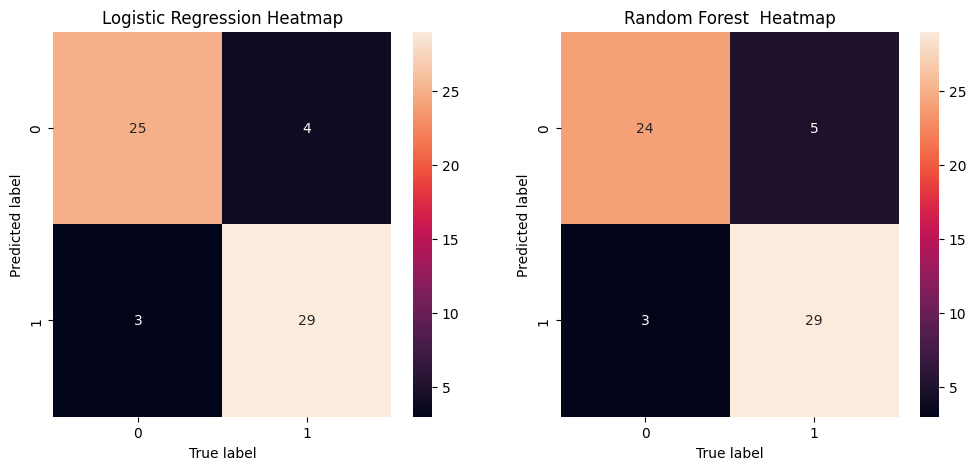

In [240]:
import seaborn as sns

fig, ax =plt.subplots(1,2,figsize=(3,3))
sns.heatmap(confusion_matrix(y_test, y_preds),
               annot=True,
               ax=ax[0])
sns.heatmap(confusion_matrix(y_test, y_preds2),
               annot=True,
               ax=ax[1])
fig.set_size_inches(12, 5)
ax[0].set_xlabel("True label")
ax[0].set_ylabel("Predicted label")

ax[1].set_xlabel("True label")
ax[1].set_ylabel("Predicted label")

ax[0].set_title("Logistic Regression Heatmap")
ax[1].set_title("Random Forest  Heatmap")
plt.show();

In [38]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



### Calculate evaluation metrics using cross-validation

Calculate precision, recall and f1_score using cross_val_score()

In [39]:
#Check best parameters

gs_log_reg.best_params_

{'C': np.float64(0.01610262027560939), 'solver': 'liblinear'}

In [40]:
#Create a new classifier with best parameters

clf=LogisticRegression(C=0.20433597178569418,
                       solver="liblinear")

In [41]:
#Cross validated accuracy

cross= cross_val_score(clf,
                            X,
                            y,
                            cv=5,
                            scoring="accuracy")
cross

array([0.81967213, 0.90163934, 0.8852459 , 0.88333333, 0.75      ])

In [42]:
cross2= cross_val_score(clf,
                        X,
                        y,
                        cv=5,
                         scoring="recall")
cross2

array([0.93939394, 0.93939394, 0.93939394, 0.93939394, 0.87878788])

In [43]:
cross3= cross_val_score(clf,
                        X,
                        y,
                        cv=5,
                         scoring="f1")
cross3

array([0.84931507, 0.91176471, 0.89855072, 0.89855072, 0.79452055])

<Axes: title={'center': 'Cross-Validated Metrics'}>

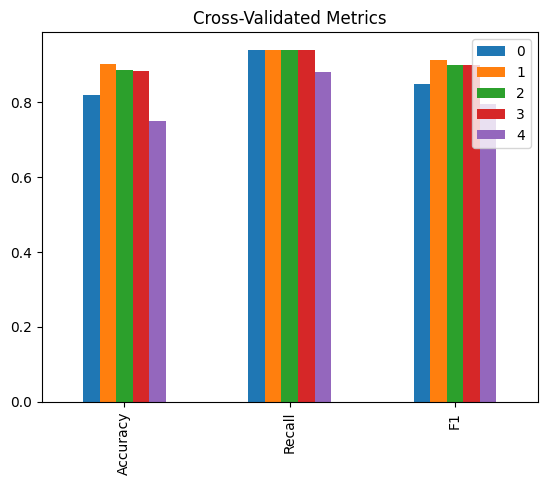

In [44]:
#Visualize cross-validated metrics

cv_metrics=pd.DataFrame({"Accuracy" : cross,
                         "Recall" : cross2,
                         "F1" : cross3})
cv_metrics.T.plot.bar(title="Cross-Validated Metrics",legend=True)